### Task 1 — Repository Setup

Fork this repository and clone it. Verify the folder structure matches what's described in the main [README](../README.md). Install dependencies with `pip install -r requirements.txt`. 

### Task 2 — API Exploration

In `notebooks/day_01_exploration.ipynb`: 

1. **Make your first API call.** Fetch one year of daily historical data for Baku (latitude 40.41, longitude 49.87). Print the response structure and identify all available fields.
2. **Visualise a sample.** Plot the daily maximum temperature for the year. Note any gaps or anomalies.
3. **Try the forecast endpoint.** Fetch the current 7-day forecast for the same city. Compare the response structure to the historical endpoint.
4. **Experiment with parameters.** Add at least 3 more weather variables (e.g., precipitation, wind speed, humidity). Document what each variable represents and its unit.

In [1]:
# Beyləqan,imişli,saatlı,sabirabad,bərdə

In [14]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 40.3777,
	"longitude": 49.892,
	"start_date": "2025-04-19",
	"end_date": "2026-04-19",
	"daily": ["temperature_2m_max", "sunshine_duration", "precipitation_sum", "wind_speed_10m_max", "soil_temperature_0_to_7cm_mean", "soil_moisture_7_to_28cm_mean", "relative_humidity_2m_mean", "temperature_2m_min"],
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_sunshine_duration = daily.Variables(1).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(2).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(3).ValuesAsNumpy()
daily_soil_temperature_0_to_7cm_mean = daily.Variables(4).ValuesAsNumpy()
daily_soil_moisture_7_to_28cm_mean = daily.Variables(5).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(6).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(7).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["sunshine_duration"] = daily_sunshine_duration
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["soil_temperature_0_to_7cm_mean"] = daily_soil_temperature_0_to_7cm_mean
daily_data["soil_moisture_7_to_28cm_mean"] = daily_soil_moisture_7_to_28cm_mean
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["temperature_2m_min"] = daily_temperature_2m_min

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe) 

Coordinates: 40.375°N 49.875°E
Elevation: -15.0 m asl
Timezone difference to GMT+0: 0s

Daily data
                          date  temperature_2m_max  sunshine_duration  \
0   2025-04-19 00:00:00+00:00           14.560500       46751.640625   
1   2025-04-20 00:00:00+00:00           14.860500       32228.648438   
2   2025-04-21 00:00:00+00:00           16.560501       46322.136719   
3   2025-04-22 00:00:00+00:00           17.860500       42643.503906   
4   2025-04-23 00:00:00+00:00           18.510500       38926.949219   
..                        ...                 ...                ...   
361 2026-04-15 00:00:00+00:00           14.610500       41711.781250   
362 2026-04-16 00:00:00+00:00           16.060499       46463.085938   
363 2026-04-17 00:00:00+00:00           15.260500       46552.402344   
364 2026-04-18 00:00:00+00:00           15.460501       46641.289062   
365 2026-04-19 00:00:00+00:00           19.060501       43192.558594   

     precipitation_sum  wind_speed_

In [3]:
df

,date,temperature_2m_mean,temperature_2m_max,sunshine_duration,precipitation_sum,wind_gusts_10m_max,soil_temperature_0_to_7cm_mean,soil_moisture_0_to_7cm_mean,relative_humidity_2m_mean,et0_fao_evapotranspiration_sum,temperature_2m_min,shortwave_radiation_sum
0,2025-01-01 00:00:00+00:00,5.550000,11.300000,30464.929688,0.0,16.919998,6.050000,0.402417,77.404961,1.062498,1.00,8.460000
1,2025-01-02 00:00:00+00:00,3.972917,10.600000,30437.894531,0.0,12.599999,4.833333,0.396708,79.086288,0.984244,-0.80,8.550000
2,2025-01-03 00:00:00+00:00,3.870833,11.100000,31116.070312,0.0,16.199999,3.472917,0.391458,75.780113,1.019727,-1.70,8.830000
3,2025-01-04 00:00:00+00:00,5.050001,12.000000,31438.685547,0.0,20.160000,2.120833,0.397458,56.664341,1.532465,-2.10,9.060000
4,2025-01-05 00:00:00+00:00,6.472917,13.550000,31020.750000,0.0,42.480000,5.529166,0.404542,64.879227,1.440095,-0.15,8.870000
...,...,...,...,...,...,...,...,...,...,...,...,...
469,2026-04-15 00:00:00+00:00,11.016666,16.100000,43200.000000,0.0,28.440001,12.306251,0.422833,67.080261,3.382972,6.45,22.400000
470,2026-04-16 00:00:00+00:00,11.497916,17.799999,43200.000000,0.0,20.160000,12.633332,0.388417,75.685005,3.525069,5.15,23.110001
471,2026-04-17 00:00:00+00:00,12.050000,17.799999,31721.535156,0.0,24.840000,12.874999,0.359000,80.009071,3.033927,6.45,19.340000
472,2026-04-18 00:00:00+00:00,13.074998,18.150000,28240.394531,0.0,19.799999,13.739582,0.338375,84.558411,2.850191,8.00,18.340000


In [4]:
df["time"] = pd.to_datetime(df["date"]) 

In [5]:
df

,date,temperature_2m_mean,temperature_2m_max,sunshine_duration,precipitation_sum,wind_gusts_10m_max,soil_temperature_0_to_7cm_mean,soil_moisture_0_to_7cm_mean,relative_humidity_2m_mean,et0_fao_evapotranspiration_sum,temperature_2m_min,shortwave_radiation_sum,time
0,2025-01-01 00:00:00+00:00,5.550000,11.300000,30464.929688,0.0,16.919998,6.050000,0.402417,77.404961,1.062498,1.00,8.460000,2025-01-01 00:00:00+00:00
1,2025-01-02 00:00:00+00:00,3.972917,10.600000,30437.894531,0.0,12.599999,4.833333,0.396708,79.086288,0.984244,-0.80,8.550000,2025-01-02 00:00:00+00:00
2,2025-01-03 00:00:00+00:00,3.870833,11.100000,31116.070312,0.0,16.199999,3.472917,0.391458,75.780113,1.019727,-1.70,8.830000,2025-01-03 00:00:00+00:00
3,2025-01-04 00:00:00+00:00,5.050001,12.000000,31438.685547,0.0,20.160000,2.120833,0.397458,56.664341,1.532465,-2.10,9.060000,2025-01-04 00:00:00+00:00
4,2025-01-05 00:00:00+00:00,6.472917,13.550000,31020.750000,0.0,42.480000,5.529166,0.404542,64.879227,1.440095,-0.15,8.870000,2025-01-05 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,2026-04-15 00:00:00+00:00,11.016666,16.100000,43200.000000,0.0,28.440001,12.306251,0.422833,67.080261,3.382972,6.45,22.400000,2026-04-15 00:00:00+00:00
470,2026-04-16 00:00:00+00:00,11.497916,17.799999,43200.000000,0.0,20.160000,12.633332,0.388417,75.685005,3.525069,5.15,23.110001,2026-04-16 00:00:00+00:00
471,2026-04-17 00:00:00+00:00,12.050000,17.799999,31721.535156,0.0,24.840000,12.874999,0.359000,80.009071,3.033927,6.45,19.340000,2026-04-17 00:00:00+00:00
472,2026-04-18 00:00:00+00:00,13.074998,18.150000,28240.394531,0.0,19.799999,13.739582,0.338375,84.558411,2.850191,8.00,18.340000,2026-04-18 00:00:00+00:00


In [6]:
import matplotlib.pyplot as plt

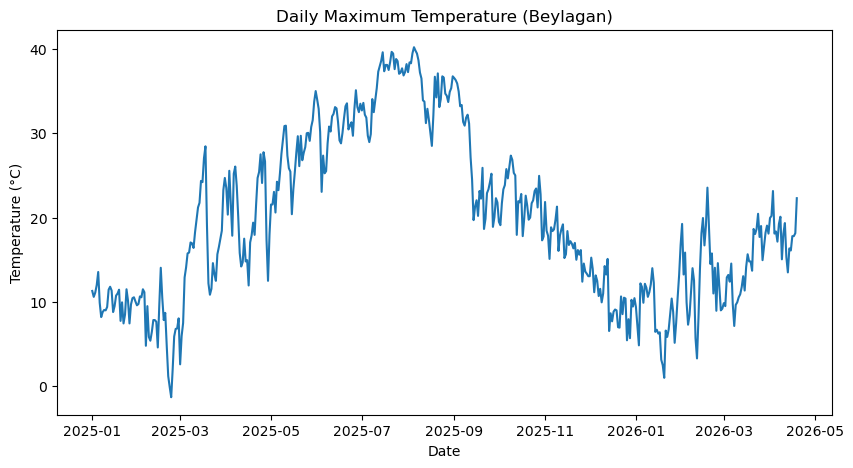

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["temperature_2m_max"])
plt.title("Daily Maximum Temperature (Beylagan)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show() 

In [ ]:
# I need to see if any month day contains any anomaliya or not

In [8]:
df["time"] = pd.to_datetime(df["time"])
df["year_month"] = df["time"].dt.to_period("M") 

C:\Users\User\AppData\Local\Temp\ipykernel_14192\82565467.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["time"].dt.to_period("M")


In [9]:
monthly_stats = df.groupby("year_month").agg({
    "temperature_2m_max": "max",
    "temperature_2m_min": "min"
})

print(monthly_stats) 

            temperature_2m_max  temperature_2m_min
year_month                                        
2025-01              13.550000           -3.550000
2025-02              14.050000           -8.600000
2025-03              28.450001           -5.150000
2025-04              27.750000            5.500000
2025-05              35.000000            9.100000
2025-06              35.099998           15.400000
2025-07              39.650002           21.200001
2025-08              40.200001           19.700001
2025-09              36.549999           11.250000
2025-10              27.350000            6.950000
2025-11              21.850000            2.300000
2025-12              15.250000           -2.850000
2026-01              16.750000           -5.300000
2026-02              23.549999           -2.050000
2026-03              20.450001            0.150000
2026-04              23.150000            5.150000


In [10]:
# As you can see there is not any anomalies or nans. We have demonstrated it with the help of visualization and some code lines.
# Some small fluctuations are visible, no major gaps detected in the time series.

In [11]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 39.7756,
	"longitude": 47.6186,
	"daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "wind_speed_10m_max"],
	"past_days": 0,
	"forecast_days": 7,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(1).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(2).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(3).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max 

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe) 

Coordinates: 39.75°N 47.625°E
Elevation: 61.0 m asl
Timezone difference to GMT+0: 0s

Daily data
                        date  temperature_2m_max  temperature_2m_min  \
0 2026-04-20 00:00:00+00:00           17.269501           10.769500   
1 2026-04-21 00:00:00+00:00           12.019500            8.269500   
2 2026-04-22 00:00:00+00:00           20.819500            8.669499   
3 2026-04-23 00:00:00+00:00           25.169500            9.969500   
4 2026-04-24 00:00:00+00:00           16.969501           11.869500   
5 2026-04-25 00:00:00+00:00           20.055000           10.911500   
6 2026-04-26 00:00:00+00:00           22.661501            9.311500   

   precipitation_sum  wind_speed_10m_max  
0                1.4           17.974781  
1                7.2           12.245293  
2                0.0            8.557102  
3                0.0           18.430452  
4                0.0           13.479583  
5                0.0           23.532547  
6                0.0            

| Feature     | Historical         | Forecast               |
| ----------- | ------------------ | ---------------------- |
| Data source | Past weather       | Predicted weather      |
| Time range  | 1 year             | 7 days                 |
| Accuracy    | Real measured data | Model-based prediction | 

In [13]:
# We already had strong features, so let's just write how will they help us. 

- soil_moisture_0_to_7cm_mean

Why it’s good:
Directly measures water available in top soil layer
Critical for seed germination and early plant growth
Strong predictor of crop yield
Interpretation:

Low soil moisture → drought stress
High soil moisture → good irrigation conditions

- relative_humidity_2m_mean

Why it’s good:
Affects plant transpiration and disease risk
High humidity → fungal diseases
Low humidity → faster evaporation (dry stress)
Interpretation:

Helps model plant stress and evaporation conditions

- shortwave_radiation_sum

Why it’s good:
Measures sunlight energy reaching surface
Direct driver of photosynthesis
Very important for crop productivity
Interpretation:

More radiation → higher potential crop growth (if water is sufficient) 

### Task 3 — City & Variable Selection 

Choose your 3+ cities and document: 

| City | Latitude | Longitude | Why this city? | 
|------|----------|-----------|----------------| 
| Baku | 40.41 | 49.87 | Home city, local relevance | 
| ... | ... | ... | ... |

Choose at least **6 daily weather variables** you will track. For each variable, note: name, unit, and why it is relevant to your analysis.

| City     | Latitude | Longitude | Why this city?                                                              |
| -------- | -------- | --------- | --------------------------------------------------------------------------- |
| Baku     | 40.41    | 49.87     | Capital city, baseline for comparison and main data source                  |
| Ganja    | 40.69    | 46.36     | Important agricultural region with different climate from Baku              |
| Lankaran | 38.75    | 48.85     | Humid subtropical climate, strong agricultural activity (tea, rice, citrus) |

| Variable                    | Unit  | Why it is relevant                                               |
| --------------------------- | ----- | ---------------------------------------------------------------- |
| temperature_2m_max          | °C    | Measures daily heat stress affecting crop growth and yield       |
| temperature_2m_min          | °C    | Important for frost detection and plant survival conditions      |
| precipitation_sum           | mm    | Direct indicator of water availability for crops                 |
| soil_moisture_0_to_7cm_mean | m³/m³ | Shows water availability in root zone (critical for germination) |
| relative_humidity_2m_mean   | %     | Impacts plant transpiration and disease risk (fungal growth)     |
| wind_speed_10m_max          | m/s   | Affects evaporation rate and can physically damage crops         |


Additional variables such as sunshine_duration and evapotranspiration were also considered for extended agricultural modeling, as they reflect solar energy input and water loss from soil and plants.

## Project Plan

### Problem Statement

The goal of this project is to investigate whether historical weather data can be used to reliably model and predict agricultural conditions relevant to cotton production.

Specifically, the project aims to answer the following question:

**“Can we predict temperature anomalies or crop-relevant environmental conditions based on historical weather patterns, and how reliable are these predictions given the quality of the data?”**

Rather than predicting exact crop yield (which requires external agricultural datasets), the focus is on modeling **weather-driven conditions** such as heat stress, water availability, and seasonal patterns that directly influence crop productivity.

This aligns with the broader project theme: *Can we trust this data?*

---

### Data Sources

All data will be collected from the **Open-Meteo API**, which provides free access to historical and forecast weather data.

Two endpoints will be used:

- **Historical Data (Archive API)**  
  Used to collect long-term daily weather data (5+ years) for each selected city  
  Example parameters:
  - temperature (mean, max, min)
  - precipitation
  - humidity
  - wind speed
  - solar radiation
  - soil moisture
  - evapotranspiration

- **Forecast Data (Forecast API)**  
  Used to retrieve 7-day weather forecasts for comparison with historical patterns and potential future prediction use cases

No API key is required, which ensures reproducibility and accessibility.

---

### Cities and Variables

#### Selected Cities

The following cities were selected:

- Saatli  
- Sabirabad  
- Imishli  
- Beylagan  
- Barda  

These cities are all located in the **central lowland agricultural region of Azerbaijan**, where cotton production is highly concentrated.

The selection strategy is intentional:

- These regions share **similar agricultural practices**, allowing the model to focus on meaningful environmental patterns rather than unrelated variability  
- At the same time, they exhibit **small differences in temperature, irrigation, and soil conditions**, which helps the model learn useful distinctions  
- The regions are known for **hot summers and irrigation-based farming**, making them ideal for studying heat stress and water-related variables  

This creates a balance between **consistency (for learning patterns)** and **variation (for model robustness)**.

---

#### Selected Weather Variables

The selected variables aim to capture the most important environmental factors affecting crop growth:

- **Temperature (mean, max, min)**  
  Core driver of plant development and stress  
  Maximum temperature is especially important for detecting heat stress  

- **Precipitation (precipitation_sum)**  
  Indicates natural water input and irrigation needs  

- **Relative Humidity**  
  Affects plant health, transpiration, and disease risk  

- **Sunshine Duration & Shortwave Radiation**  
  Represent solar energy available for photosynthesis and biomass production  

- **Wind Speed**  
  Influences evaporation, water loss, and physical stress on crops  

- **Evapotranspiration (ET₀)**  
  A critical agricultural metric that estimates how much water is lost from soil and plants  
  Helps measure drought stress and irrigation demand  

- **Soil Moisture (top layer)**  
  Direct indicator of water availability for plant roots  

These variables were selected to represent four key dimensions:

1. Temperature conditions  
2. Water availability  
3. Solar energy  
4. Soil and atmospheric interactions  

Together, they provide a **comprehensive view of the agricultural environment**.

---

### Methodology

The project is divided into two main phases:

#### Week 1 — Data Engineering

Focus: Building a reliable data pipeline

- Collect historical weather data from the API  
- Structure and store data in a clean format  
- Perform data cleaning and validation  
- Identify missing values and inconsistencies  
- Conduct initial exploratory data analysis (EDA)  
- Create basic features (e.g., monthly averages, seasonal indicators)  

This phase ensures the dataset is accurate, consistent, and suitable for modeling.

---

#### Week 2 — Statistical Analysis & Prediction

Focus: Extracting insights and building models

- Perform statistical analysis (distributions, correlations)  
- Evaluate relationships between variables  
- Conduct hypothesis testing (e.g., seasonal differences)  
- Engineer advanced features (extreme events, variability)  
- Train predictive models:
  - Logistic Regression (baseline)
  - Random Forest (non-linear model)  
- Evaluate and compare model performance  
- Interpret results and assess reliability  

This phase focuses on understanding patterns and building predictive capability.

---

### Success Criteria

The project will be considered successful if:

- The model achieves **strong predictive performance**  
  (e.g., Accuracy > 0.75 and a balanced F1 Score)

- The analysis identifies **meaningful relationships** between weather variables and agricultural conditions  

- The pipeline is:
  - clean  
  - reproducible  
  - well-structured  

- Data quality issues (missing values, anomalies, inconsistencies) are:
  - clearly identified  
  - properly handled  
  - critically evaluated  

- The final results provide **useful insights into how climate affects agricultural conditions**, even if perfect prediction is not achieved  

Ultimately, success is not only about model accuracy, but also about **understanding the reliability and limitations of the data**. 